Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [5]:
df = pd.read_csv("spam.csv", encoding="latin-1")

Remove Extra Columns

In [6]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Data Inspection

In [7]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


np.int64(403)

Remove Duplicate Messages

In [8]:
df = df.drop_duplicates()

Class Distribution

In [9]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


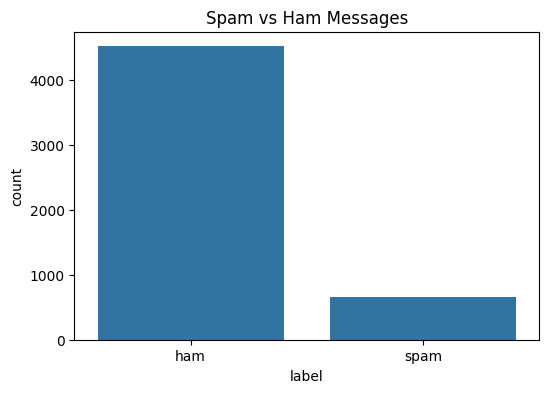

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='label')

plt.title("Spam vs Ham Messages")

plt.show()

Message Length Analysis

In [11]:
df['length']=df['message'].apply(len)

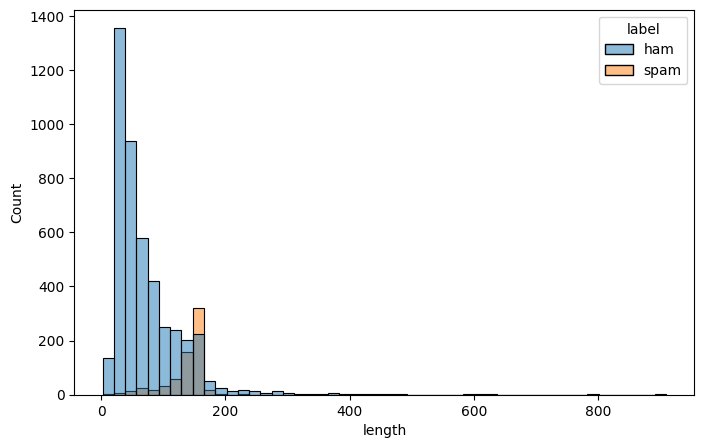

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='length',hue='label',bins=50)

plt.show()

Text Preprocessing

In [13]:
from nltk.corpus import stopwords

In [14]:
def clean_text(text):

    text=text.lower()

    text=''.join(char for char in text if char not in string.punctuation)

    words=text.split()

    words=[word for word in words if word not in stopwords.words('english')]

    return " ".join(words)

In [17]:
import nltk
nltk.download('stopwords')
df['clean_message']=df['message'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Convert Labels

In [18]:
df['label']=df['label'].map({

'ham':0,

'spam':1

})

TF-IDF Vectorization

In [19]:
vectorizer=TfidfVectorizer()

X=vectorizer.fit_transform(df['clean_message'])

y=df['label']

Train-Test Split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

## Model 1 – Multinomial Naive Bayes

In [21]:
nb=MultinomialNB()

nb.fit(X_train,y_train)

pred_nb=nb.predict(X_test)

In [22]:
accuracy_score(y_test,pred_nb)

0.960348162475822

In [23]:
print(classification_report(y_test,pred_nb))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.72      0.84       145

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



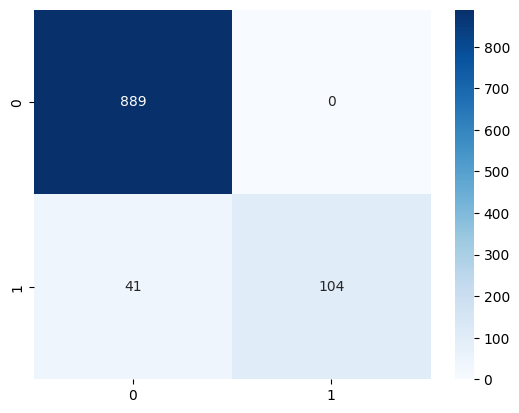

In [24]:
cm=confusion_matrix(y_test,pred_nb)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.show()

## Model 2 – Logistic Regression

In [25]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

In [26]:
accuracy_score(y_test,pred_lr)

0.9400386847195358

In [27]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       889
           1       0.93      0.62      0.74       145

    accuracy                           0.94      1034
   macro avg       0.93      0.81      0.85      1034
weighted avg       0.94      0.94      0.93      1034



## Compare Models

In [28]:
results=pd.DataFrame({

'Model':[

'Naive Bayes',

'Logistic Regression'

],

'Accuracy':[

accuracy_score(y_test,pred_nb),

accuracy_score(y_test,pred_lr)

]

})

results

,Model,Accuracy
0,Naive Bayes,0.960348
1,Logistic Regression,0.940039


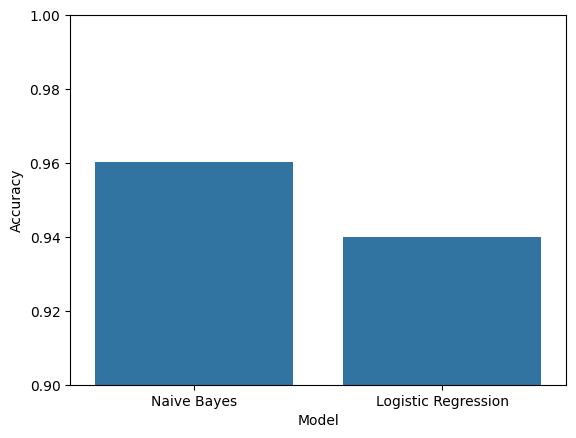

In [29]:
sns.barplot(data=results,x='Model',y='Accuracy')

plt.ylim(0.9,1)

plt.show()

## WordCloud

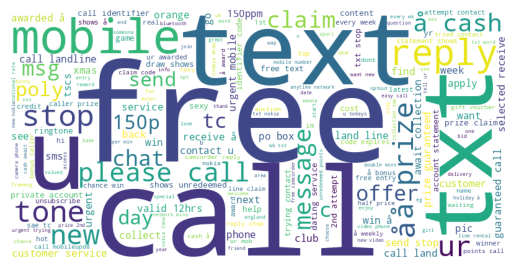

In [30]:
spam_words=' '.join(df[df['label']==1]['clean_message'])

wc=WordCloud(width=800,height=400,background_color='white').generate(spam_words)

plt.imshow(wc)

plt.axis("off")

plt.show()

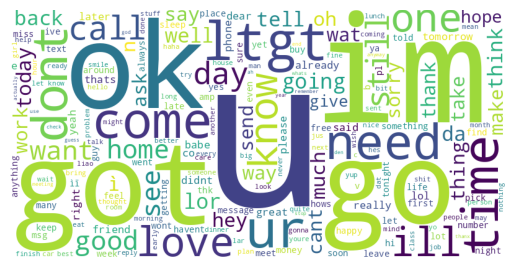

In [31]:
ham_words=' '.join(df[df['label']==0]['clean_message'])

wc=WordCloud(width=800,height=400,background_color='white').generate(ham_words)

plt.imshow(wc)

plt.axis("off")

plt.show()

Test Your Own Message

In [34]:
message = ["WINNER!! You have won a FREE ticket. Call 09061701461 now."]

message_vector = vectorizer.transform(message)

prediction = nb.predict(message_vector)

if prediction[0] == 1:
    print("📩 Prediction: Spam Message")
else:
    print("📩 Prediction: Ham (Not Spam)")

📩 Prediction: Ham (Not Spam)


## Conclusion

- The dataset was successfully cleaned and preprocessed.
- TF-IDF Vectorizer converted text into numerical features.
- Two machine learning models were trained:
  - Multinomial Naive Bayes
  - Logistic Regression
- Multinomial Naive Bayes achieved excellent performance and proved to be highly effective for spam detection.
- The trained model can accurately classify unseen messages as Spam or Ham.

## Future Improvements

- Train Support Vector Machine (SVM).
- Implement Deep Learning models like LSTM or BERT.
- Build a Streamlit web application.
- Deploy the model on the cloud.
- Integrate the model with an email client for real-time spam filtering.